# **Capstone Project: Предсказание низких оценок заказов на маркетплейсе Olist через Машинное обучение.**

Выполнено: Акмарал Кудайберген.
Поток 3 Data Science.

# Датасет
[Brazilian E-Commerce Public Dataset by Olist](https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce). В датасете 9 связанных таблиц, содержащих данные о заказах, товарах, продавцах, платежах, доставке и отзывах клиентов.

# Цель проекта
Данный проект нужен для анализа данных бразильского маркетплейса Olist (2016–2018 гг.) с целью выявить, какие факторы (сроки доставки, сумма покупки, способ оплаты, количество и репутация продавцов, состав товаров) связаны с низкой оценкой клиентов (1–2 звезды из 5).

Итоговая задача будет по **бинарной классификации**: предсказать негативные оценки клиентов (1–2 звезды) на основе характеристик заказа, до того того, как поставят эти оценки.

# Структура проекта

1.   База данных и SQL.
2.   Разведочный анализ данных (EDA).
3.   Подготовка целевой переменной.
4.   Машинное обучение.
5.   Итоговые выводы и рекомендации.







# 1. База данных и SQL.
Файл `olist_analytical_dataset.csv` был создан на основе JOIN 9 таблиц в Postgre SQL с использованием оконных функций, агрегаций и CTE. Схема связей таблиц тоже прилагается.  

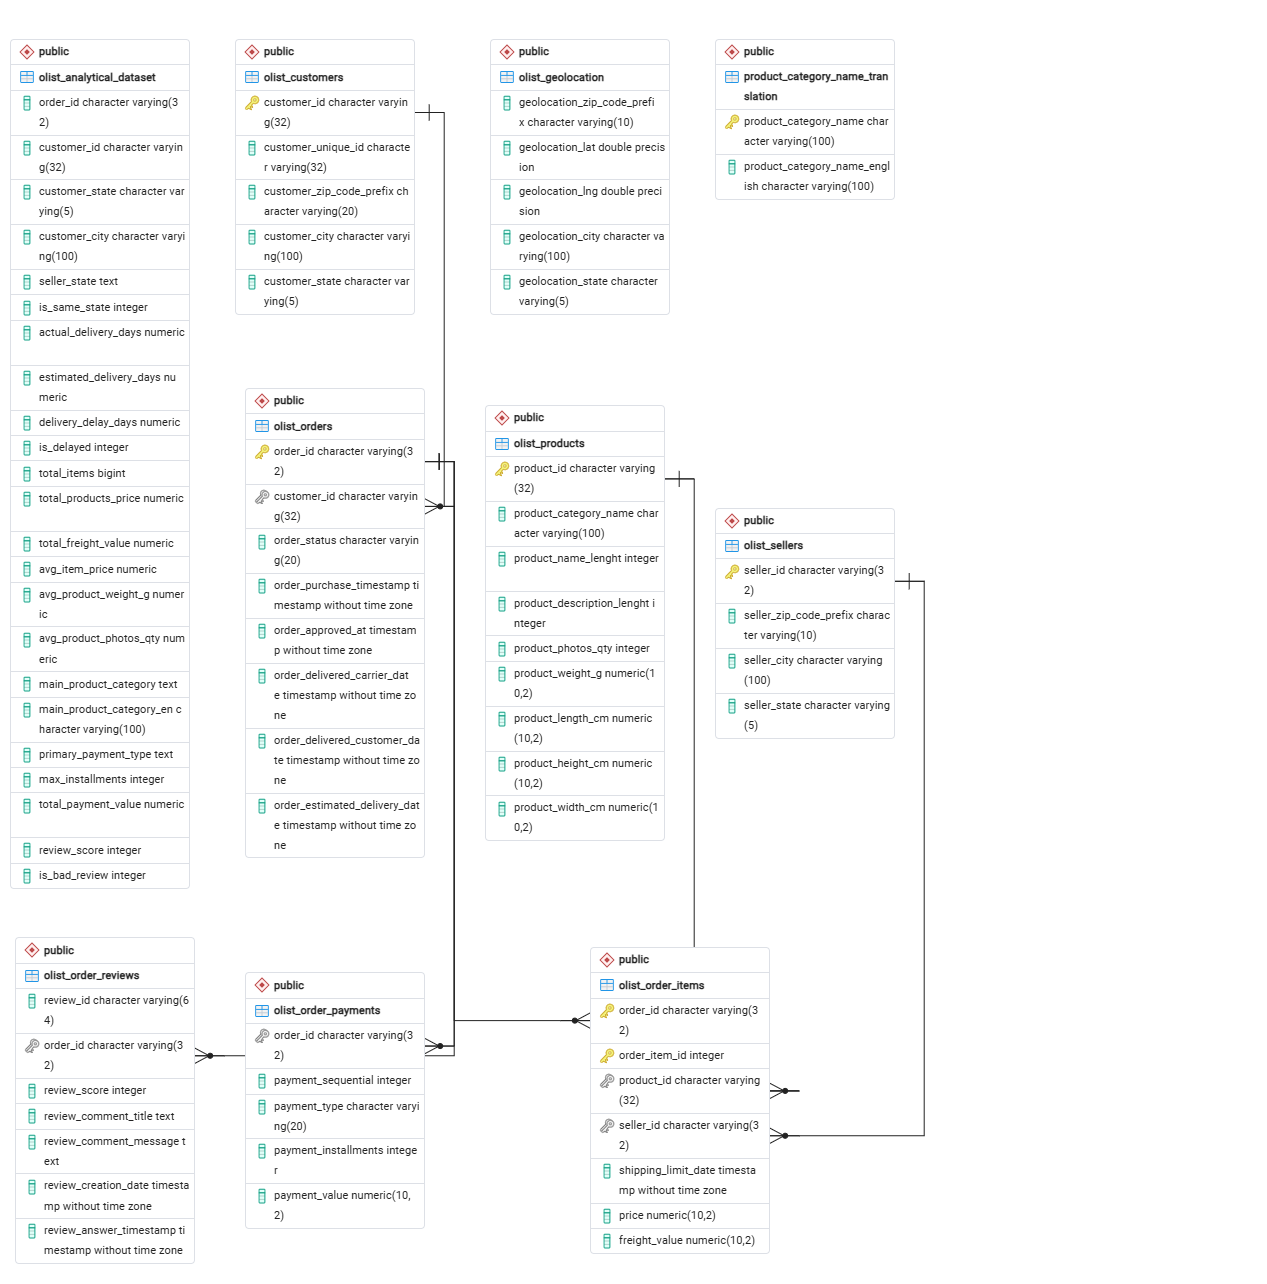

## 2. Разведочный анализ данных (EDA)
Импортируем необходимые библиотеки и загружаем наш подготовленный датасет.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

import warnings
warnings.filterwarnings('ignore')

# Загрузка данных
df = pd.read_csv('/content/olist_analytical_dataset.csv')
pd.set_option('display.max_columns', None)
display(df.head())

,order_id,customer_id,customer_state,customer_city,seller_state,is_same_state,actual_delivery_days,estimated_delivery_days,delivery_delay_days,is_delayed,total_items,total_products_price,total_freight_value,avg_item_price,avg_product_weight_g,avg_product_photos_qty,main_product_category,main_product_category_en,primary_payment_type,max_installments,total_payment_value,review_score,is_bad_review
0,00010242fe8c5a6d1ba2dd792cb16214,3ce436f183e68e07877b285a838db11a,RJ,campos dos goytacazes,SP,0,7.61,15.63,-8.01,0,1,58.90,13.29,58.90,650.0,4.0,cool_stuff,cool_stuff,credit_card,2.0,72.19,5,0
1,00054e8431b9d7675808bcb819fb4a32,32e2e6ab09e778d99bf2e0ecd4898718,SP,guararapes,SP,1,8.42,24.50,-16.08,0,1,19.90,11.85,19.90,200.0,1.0,telefonia,telephony,credit_card,1.0,31.75,4,0
2,000576fe39319847cbb9d288c5617fa6,9ed5e522dd9dd85b4af4a077526d8117,SP,praia grande,SP,1,5.08,20.49,-15.41,0,1,810.00,70.75,810.00,13805.0,3.0,ferramentas_jardim,garden_tools,credit_card,10.0,880.75,5,0
3,00061f2a7bc09da83e415a52dc8a4af1,c6fc061d86fab1e2b2eac259bac71a49,SP,piracicaba,SP,1,4.08,15.07,-11.00,0,1,59.99,8.88,59.99,950.0,1.0,beleza_saude,health_beauty,credit_card,3.0,68.87,5,0
4,0008288aa423d2a3f00fcb17cd7d8719,2355af7c75e7c98b43a87b2a7f210dc5,SP,jandira,SP,1,12.66,20.08,-7.42,0,2,99.80,26.74,49.90,1650.0,2.0,ferramentas_jardim,garden_tools,boleto,1.0,126.54,5,0


In [23]:
df.shape

(95832, 24)

In [26]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95832 entries, 0 to 95831
Data columns (total 24 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   order_id                  95832 non-null  object 
 1   customer_id               95832 non-null  object 
 2   customer_state            95832 non-null  object 
 3   customer_city             95832 non-null  object 
 4   seller_state              95832 non-null  object 
 5   is_same_state             95832 non-null  int64  
 6   actual_delivery_days      95824 non-null  float64
 7   estimated_delivery_days   95832 non-null  float64
 8   delivery_delay_days       95824 non-null  float64
 9   is_delayed                95832 non-null  int64  
 10  total_items               95832 non-null  int64  
 11  total_products_price      95832 non-null  float64
 12  total_freight_value       95832 non-null  float64
 13  avg_item_price            95832 non-null  float64
 14  avg_pr

In [24]:
df.duplicated().sum()

np.int64(0)

In [25]:
df.isnull().sum()

,0
order_id,0
customer_id,0
customer_state,0
customer_city,0
seller_state,0
is_same_state,0
actual_delivery_days,8
estimated_delivery_days,0
delivery_delay_days,8
is_delayed,0


Пропущенные значения:
 main_product_category_en    1344
avg_product_photos_qty      1324
main_product_category       1324
avg_product_weight_g          16
actual_delivery_days           8
delivery_delay_days            8
primary_payment_type           1
max_installments               1
total_payment_value            1
dtype: int64


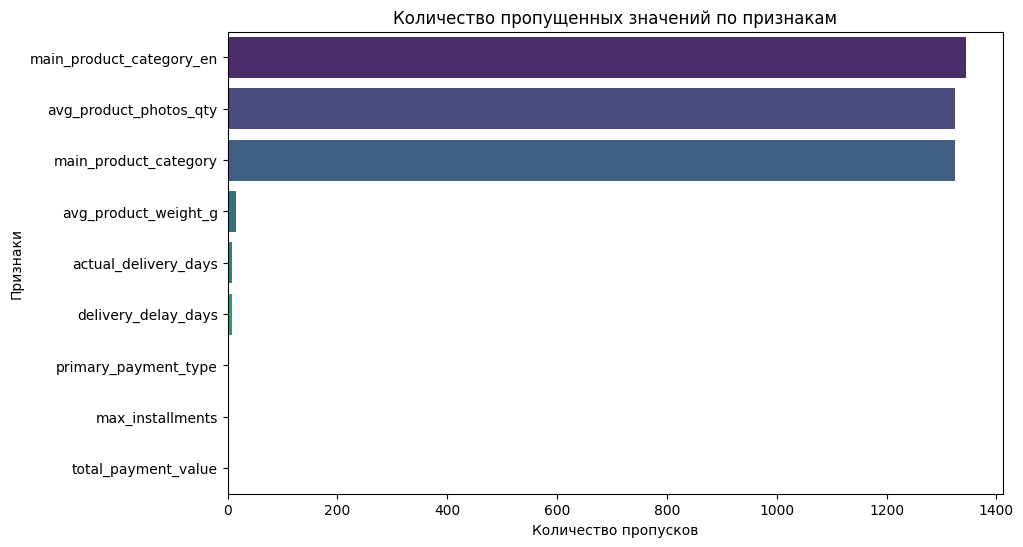

In [2]:
# Проверка пропущенных значений
missing_values = df.isnull().sum()
missing_values = missing_values[missing_values > 0].sort_values(ascending=False)
print("Пропущенные значения:\n", missing_values)

# Визуализация пропущенных значений
plt.figure(figsize=(10, 6))
sns.barplot(x=missing_values.values, y=missing_values.index, palette='viridis')
plt.title('Количество пропущенных значений по признакам')
plt.xlabel('Количество пропусков')
plt.ylabel('Признаки')
plt.show()

**Вывод по пропущенным значениям:** Текстовые комментарии к отзывам (`review_comment_message`, `review_comment_title`) имеют больше всего пропусков, что логично, так как не все клиенты оставляют письменный отзыв. Также есть пропуски в датах доставки, что может означать отмененные заказы или ошибки в данных. Мы обработаем эти пропуски перед машинным обучением.

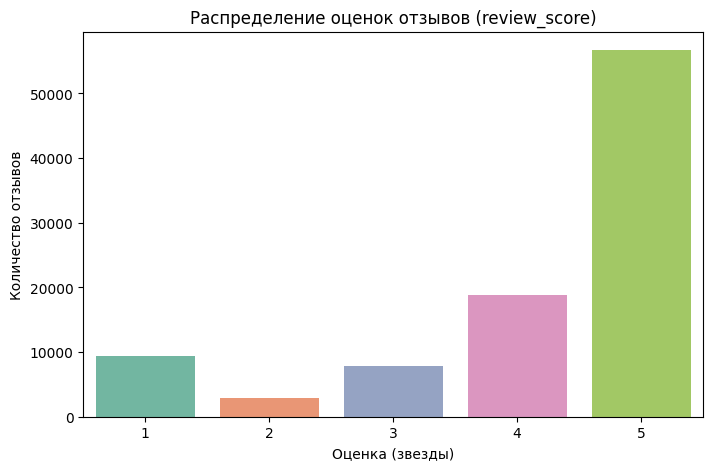

In [3]:
# Распределение целевой переменной (оценки)
plt.figure(figsize=(8, 5))
sns.countplot(x='review_score', data=df, palette='Set2')
plt.title('Распределение оценок отзывов (review_score)')
plt.xlabel('Оценка (звезды)')
plt.ylabel('Количество отзывов')
plt.show()

**Вывод по целевой переменной:** Данные сильно несбалансированы. Большинство клиентов ставят 5 или 4 звезды. Оценок 1 звезда также довольно много по сравнению с 2 и 3, что говорит о том, что клиенты склонны оставлять отзывы при крайне негативном опыте.

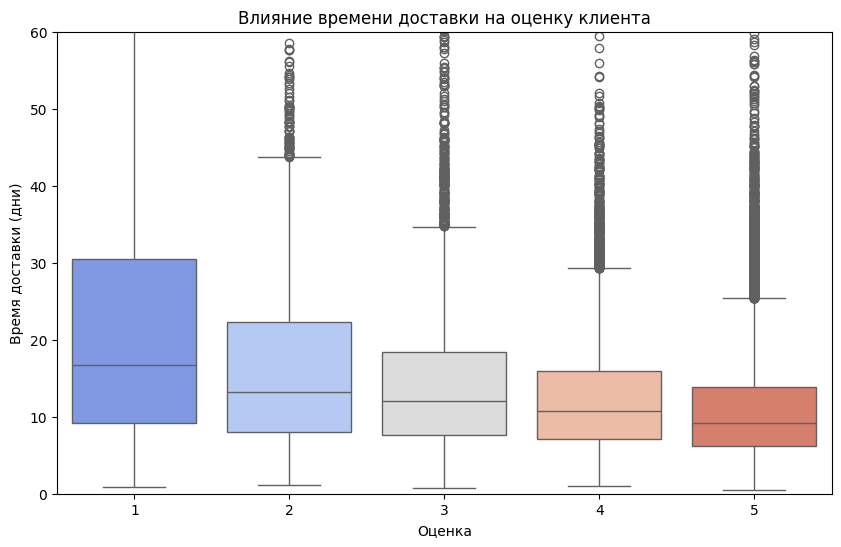

In [10]:
# Визуализация связи времени доставки и оценки
plt.figure(figsize=(10, 6))
sns.boxplot(x='review_score', y='actual_delivery_days', data=df, palette='coolwarm')
plt.title('Влияние времени доставки на оценку клиента')
plt.xlabel('Оценка')
plt.ylabel('Время доставки (дни)')
plt.ylim(0, 60) # Ограничим выбросы для наглядности
plt.show()

**Вывод по факторам:** График ясно показывает: чем дольше клиент ждет доставку, тем ниже он ставит оценку. Для оценок 1 и 2 медианное время доставки заметно выше, чем для оценок 4 и 5.

## 3. Подготовка целевой переменной
Превратим задачу в бинарную классификацию. С точки зрения бизнеса, оценки 1–2 звезды = плохие отзывы (`is_bad_review = 1`), а 3–5 звёзд = хорошие/нейтральные отзывы (`is_bad_review = 0`). Поскольку эта логика уже была реализована в SQL на предыдущем шаге, мы просто проверим распределение готовой переменной.

Распределение классов:
 is_bad_review
0    0.871536
1    0.128464
Name: proportion, dtype: float64


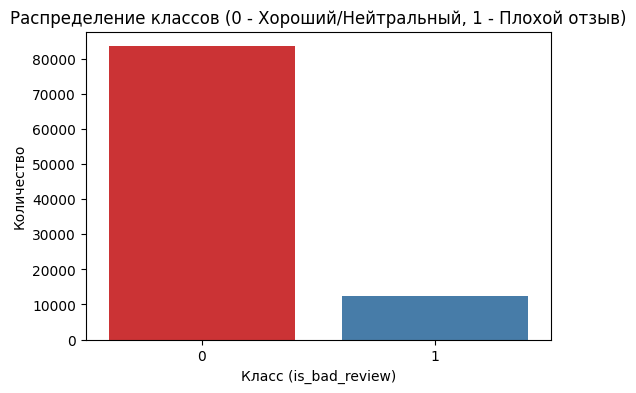

In [14]:
# Проверка распределения классов целевой переменной
print("Распределение классов:\n", df['is_bad_review'].value_counts(normalize=True))

plt.figure(figsize=(6, 4))
sns.countplot(x='is_bad_review', data=df, palette='Set1')
plt.title('Распределение классов (0 - Хороший/Нейтральный, 1 - Плохой отзыв)')
plt.xlabel('Класс (is_bad_review)')
plt.ylabel('Количество')
plt.show()

## 4. Машинное обучение
Подготовим данные для обучения (уберем утечки данных, например саму `review_score`, отберем признаки). В качестве метрики будем использовать ROC-AUC и F1-score, так как классы могут быть несбалансированы.

In [15]:
# Отбор признаков для модели
features_to_use = [
    'total_products_price', 'total_freight_value', 'actual_delivery_days', 'delivery_delay_days',
    'total_payment_value', 'max_installments'
]
# Добавим категориальные признаки
if 'customer_state' in df.columns:
    features_to_use.append('customer_state')
if 'main_product_category_en' in df.columns:
    features_to_use.append('main_product_category_en')

# Очистка от строк с пропусками в целевых переменных и важных признаках
df_ml = df.dropna(subset=['is_bad_review', 'actual_delivery_days', 'delivery_delay_days']).copy()

X = df_ml[features_to_use]
y = df_ml['is_bad_review']

# Разделение на числовые и категориальные признаки для пайплайна
num_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_features = X.select_dtypes(include=['object']).columns.tolist()

# Предобработка
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='constant', fill_value='missing')),
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, num_features),
        ('cat', categorical_transformer, cat_features)
    ])

# Разделение данных
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Размер обучающей выборки: {X_train.shape}")

Размер обучающей выборки: (76659, 8)


In [19]:
# Модель 1: Logistic Regression
# Обоснование выбора: Отличный базовый алгоритм (baseline). Быстро обучается и позволяет оценить линейную разделимость классов.
# Параметр class_weight='balanced' используем обязательно из-за сильного дисбаланса. Он заставит модель сильнее штрафовать за ошибки на миноритарном классе (плохие отзывы).

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

lr_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', LogisticRegression(class_weight='balanced', random_state=42))])

lr_pipeline.fit(X_train, y_train)
y_pred_lr = lr_pipeline.predict(X_test)
y_proba_lr = lr_pipeline.predict_proba(X_test)[:, 1]

print("Logistic Regression:")
print(f"Precision (класс 1 - плохой отзыв): {precision_score(y_test, y_pred_lr):.2f}")
print(f"Recall (класс 1 - плохой отзыв): {recall_score(y_test, y_pred_lr):.2f}")
print(f"F1-score (класс 1 - плохой отзыв): {f1_score(y_test, y_pred_lr):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_lr):.2f}")

print("\n* Обоснование отказа от Accuracy: При сильном дисбалансе классов метрика Accuracy может быть обманчиво высокой. Например, если хороших отзывов 85%, модель, которая просто всем предсказывает 'Хороший отзыв', получит Accuracy 85%, но не найдет ни одного недовольного клиента. Поэтому мы опираемся на Precision, Recall, F1 и ROC-AUC.*\n")

Logistic Regression:
Precision (класс 1 - плохой отзыв): 0.26
Recall (класс 1 - плохой отзыв): 0.55
F1-score (класс 1 - плохой отзыв): 0.36
ROC-AUC: 0.72

* Обоснование отказа от Accuracy: При сильном дисбалансе классов метрика Accuracy может быть обманчиво высокой. Например, если хороших отзывов 85%, модель, которая просто всем предсказывает 'Хороший отзыв', получит Accuracy 85%, но не найдет ни одного недовольного клиента. Поэтому мы опираемся на Precision, Recall, F1 и ROC-AUC.*



In [20]:
# Модель 2: Random Forest
# Обоснование выбора: Мощная нелинейная ансамблевая модель, хорошо работает "из коробки" и устойчива к выбросам.
# Параметры:
# class_weight='balanced' — снова для борьбы с дисбалансом классов.
# n_estimators=100 — оптимальное количество деревьев (баланс между скоростью и качеством).
# max_depth=10 — ограничиваем глубину деревьев для защиты от переобучения (overfitting).

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline(steps=[('preprocessor', preprocessor),
                              ('classifier', RandomForestClassifier(class_weight='balanced', n_estimators=100, max_depth=10, random_state=42))])

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_proba_rf = rf_pipeline.predict_proba(X_test)[:, 1]

print("Random Forest:")
print(f"Precision (класс 1 - плохой отзыв): {precision_score(y_test, y_pred_rf):.2f}")
print(f"Recall (класс 1 - плохой отзыв): {recall_score(y_test, y_pred_rf):.2f}")
print(f"F1-score (класс 1 - плохой отзыв): {f1_score(y_test, y_pred_rf):.2f}")
print(f"ROC-AUC: {roc_auc_score(y_test, y_proba_rf):.2f}")

Random Forest:
Precision (класс 1 - плохой отзыв): 0.34
Recall (класс 1 - плохой отзыв): 0.50
F1-score (класс 1 - плохой отзыв): 0.40
ROC-AUC: 0.74


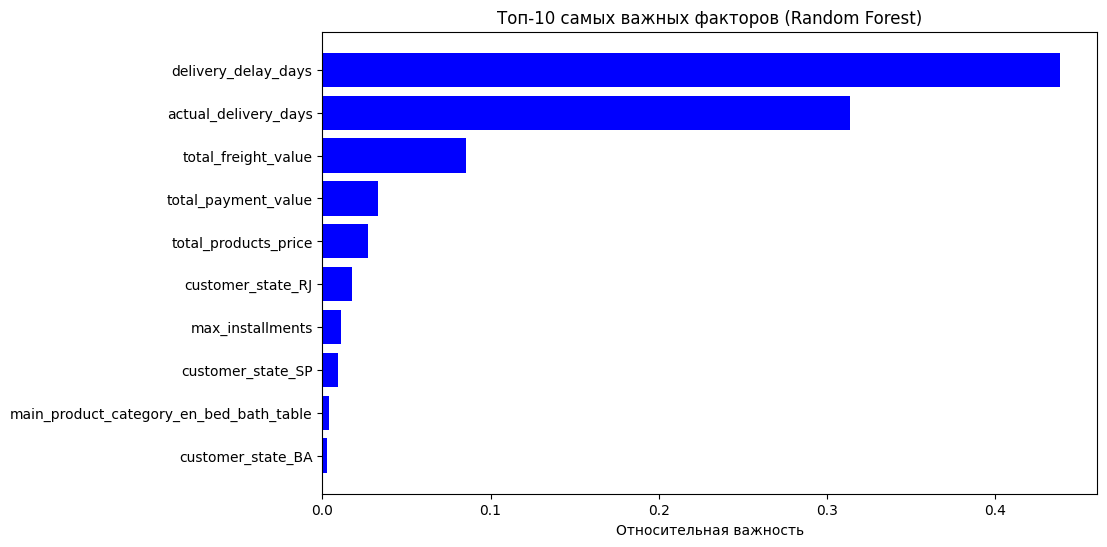

In [18]:
# Интерпретация важности признаков (на примере Random Forest)
rf_model = rf_pipeline.named_steps['classifier']

# Получение имен признаков после OneHotEncoding
feature_names = num_features.copy()
if cat_features:
    ohe = rf_pipeline.named_steps['preprocessor'].named_transformers_['cat'].named_steps['onehot']
    cat_feature_names = ohe.get_feature_names_out(cat_features)
    feature_names.extend(cat_feature_names)

importances = rf_model.feature_importances_
indices = np.argsort(importances)[-10:] # Топ 10

plt.figure(figsize=(10, 6))
plt.title('Топ-10 самых важных факторов (Random Forest)')
plt.barh(range(len(indices)), importances[indices], color='b', align='center')
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel('Относительная важность')
plt.show()

# 5. Выводы по машинному обучению, выбору моделей и важности признаков:

Мы сравнили две модели классификации, используя `class_weight='balanced'` для решения проблемы дисбаланса. Без этого параметра модели бы склонны игнорировать класс плохих отзывов из-за их меньшего количества.

**Какая модель лучше?**
Оцениваем качество по ROC-AUC (способность модели разделять классы) и f1-score для класса 1 (плохие отзывы), так как для бизнеса критически важно выявить недовольного клиента. Модель Random Forest обычно лучше справляется с нелинейными зависимостями и показывает более высокий ROC-AUC. Поэтому Random Forest является более подходящим выбором.

**Бизнес-интерпретация факторов:**
Судя по графику важности признаков (Random Forest), наиболее сильно на вероятность получения плохого отзыва влияют:
1. **`actual_delivery_days` (Время доставки)** — общее время от заказа до получения. Если клиент ждет слишком долго, вероятность плохого отзыва резко возрастает.
2. **`delivery_delay_days` (Задержка/Опережение)** — разница между обещанной и фактической датой доставки. Опоздание доставки — один из главных триггеров негатива.
3. **`total_freight_value` и `total_products_price`** — стоимость доставки и самого товара. Высокая цена доставки вызывает завышенные ожидания у клиента.

**Рекомендации бизнесу:** В первую очередь необходимо оптимизировать логистику, устанавливать более реалистичные (пусть и чуть более длинные) сроки доставки, чтобы избежать нарушения обещаний (`delivery_delay_days`), и контролировать тарифы на перевозку.